In [1]:
%run ../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset import KidneyStoneDataset
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.pipelines.hybrid_resnet50_pipeline import HybridResNet50_pipeline
import pandas as pd
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
from src.pipelines.xgboost_pipeline import XGBoostExperiment

In [3]:
#sobre las imágenes

#clasificación multiclase
task_name = "multiclase"
task_config = TASKS[task_name]
xgboost_builder= DatasetBuilder(DATASET_PATH_XGBOOST)

df = xgboost_builder.build(classes=task_config["classes"])

lbp = LocalBinaryPattern()
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)

xgboost_model= XGBoostExperiment(df, extractor, Case.IMAGE,use_energies= True)
config = {
"name": f"xgboost_images_{task_name}",
"output_dir": f"experiments/ablations/xgboost_images/xgboost_{task_name}_energy_based",
"class_names": task_config["class_names"],
}

result= xgboost_model.search_hyperparameters(config)



  Features shape: (397, 40)
  Distribución: {0: 192, 1: 24, 2: 115, 3: 35, 4: 31}

BÚSQUEDA HP: xgboost_images_multiclase
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.4787
  Best params: {'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 515, 'learning_rate': 0.03685533083591003, 'subsample': 0.9994671379954141, 'colsample_bytree': 0.6879184140939619}



EVALUACIÓN CV: xgboost_images_multiclase (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.5455 | precision_weighted=0.5965 | recall_weighted=0.5455 | f1_weighted=0.5335 | auc_weighted=0.7450
  Fold 2: accuracy=0.6889 | precision_weighted=0.6531 | recall_weighted=0.6889 | f1_weighted=0.6584 | auc_weighted=0.8614
  Fold 3: accuracy=0.6456 | precision_weighted=0.6127 | recall_weighted=0.6456 | f1_weighted=0.6216 | auc_weighted=0.8313
  Fold 4: accuracy=0.6111 | precision_weighted=0.6203 | recall_weighted=0.6111 | f1_weighted=0.5998 | auc_weighted=0.7467
  Fold 5: accuracy=0.6962 | precision_weighted=0.6954 | recall_weighted=0.6962 | f1_weighted=0.6782 | auc_weighted=0.7885

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6374 ± 0.0554
  auc_weighted: 0.7946 ± 0.0460
  f1_weighted: 0.6183 ± 0.0505
  precision_weighted: 0.6356 ± 0.0351
  recall_weighted: 0.6374 ± 0.0554


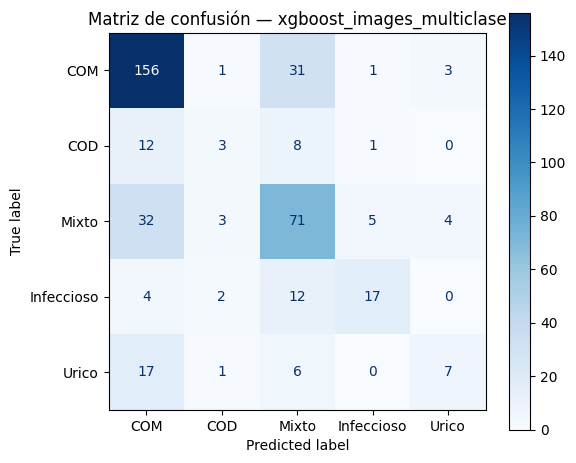

In [5]:

evaluation_result= xgboost_model.evaluate_cv(config, show_fold_metrics= True, best_params= result["best_params"])


In [8]:
#sobre las imágenes

#clasificación multiclase
task_name = "binario"
task_config = TASKS[task_name]

df = xgboost_builder.build(classes=task_config["classes"])

xgboost_model= XGBoostExperiment(df, extractor, Case.IMAGE,use_energies= True )
config = {
"name": f"xgboost_images_{task_name}",
"output_dir": f"experiments/ablations/xgboost_images/xgboost_{task_name}_energy_based",
"class_names": task_config["class_names"],
}

result= xgboost_model.search_hyperparameters(config)



  Features shape: (397, 40)
  Distribución: {0: 192, 1: 205}

BÚSQUEDA HP: xgboost_images_binario
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.8369
  Best params: {'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 313, 'learning_rate': 0.03302894501013836, 'subsample': 0.53345612579038, 'colsample_bytree': 0.48543254473874886}



EVALUACIÓN CV: xgboost_images_binario (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.8022 | precision_weighted=0.8035 | recall_weighted=0.8022 | f1_weighted=0.8024 | auc_weighted=0.8848
  Fold 2: accuracy=0.7895 | precision_weighted=0.7891 | recall_weighted=0.7895 | f1_weighted=0.7887 | auc_weighted=0.8368
  Fold 3: accuracy=0.8310 | precision_weighted=0.8303 | recall_weighted=0.8310 | f1_weighted=0.8299 | auc_weighted=0.8325
  Fold 4: accuracy=0.7722 | precision_weighted=0.7721 | recall_weighted=0.7722 | f1_weighted=0.7716 | auc_weighted=0.8526
  Fold 5: accuracy=0.6875 | precision_weighted=0.6872 | recall_weighted=0.6875 | f1_weighted=0.6873 | auc_weighted=0.7776

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7765 ± 0.0485
  auc_weighted: 0.8369 ± 0.0349
  f1_weighted: 0.7760 ± 0.0483
  precision_weighted: 0.7764 ± 0.0485
  recall_weighted: 0.7765 ± 0.0485


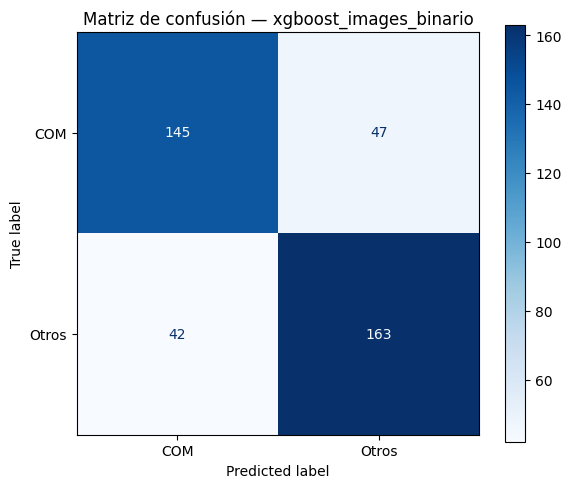

In [9]:

evaluation_result= xgboost_model.evaluate_cv(config, show_fold_metrics= True, best_params= result["best_params"])


In [6]:
#sobre las patches

#clasificación multiclase


patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")

task_name = "multiclase"
task_config = TASKS[task_name]

patches_task = assign_task_labels(patches_df_full, task_config)

xgboost_model= XGBoostExperiment(patches_task, extractor, Case.PATCH,use_energies= True )
config = {
"name": f"xgboost_images_{task_name}",
"output_dir": f"experiments/ablations/xgboost_patches/xgboost_{task_name}_energy_based",
"class_names": task_config["class_names"],
}

result= xgboost_model.search_hyperparameters(config)



  Features shape: (5290, 40)
  Distribución: {0: 2767, 1: 298, 2: 1372, 3: 485, 4: 368}

BÚSQUEDA HP: xgboost_images_multiclase
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.4404
  Best params: {'max_depth': 5, 'min_child_weight': 9, 'n_estimators': 486, 'learning_rate': 0.029430390193827285, 'subsample': 0.7089007844550044, 'colsample_bytree': 0.9765412605335411}



EVALUACIÓN CV: xgboost_images_multiclase (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.6298 | precision_weighted=0.6423 | recall_weighted=0.6298 | f1_weighted=0.6218 | auc_weighted=0.7985
  Fold 2: accuracy=0.6258 | precision_weighted=0.6108 | recall_weighted=0.6258 | f1_weighted=0.5943 | auc_weighted=0.8405
  Fold 3: accuracy=0.6444 | precision_weighted=0.6206 | recall_weighted=0.6444 | f1_weighted=0.6177 | auc_weighted=0.8083
  Fold 4: accuracy=0.5552 | precision_weighted=0.5818 | recall_weighted=0.5552 | f1_weighted=0.5448 | auc_weighted=0.7585
  Fold 5: accuracy=0.5848 | precision_weighted=0.6163 | recall_weighted=0.5848 | f1_weighted=0.5755 | auc_weighted=0.7752

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6080 ± 0.0330
  auc_weighted: 0.7962 ± 0.0282
  f1_weighted: 0.5908 ± 0.0284
  precision_weighted: 0.6144 ± 0.0195
  recall_weighted: 0.6080 ± 0.0330


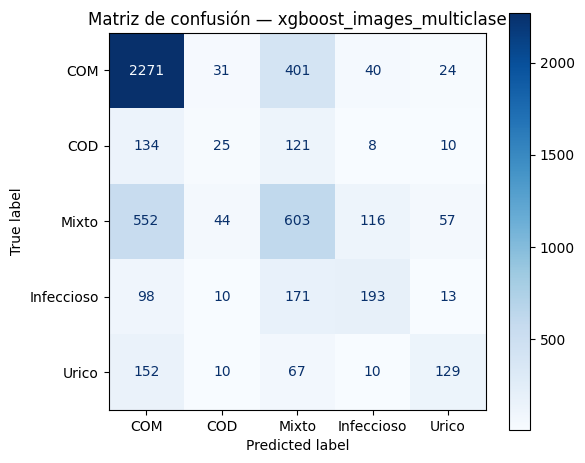


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.6390 ± 0.0177
  auc_weighted: 0.8471 ± 0.0383
  f1_weighted: 0.6021 ± 0.0206
  precision_weighted: 0.6372 ± 0.0236
  recall_weighted: 0.6390 ± 0.0177


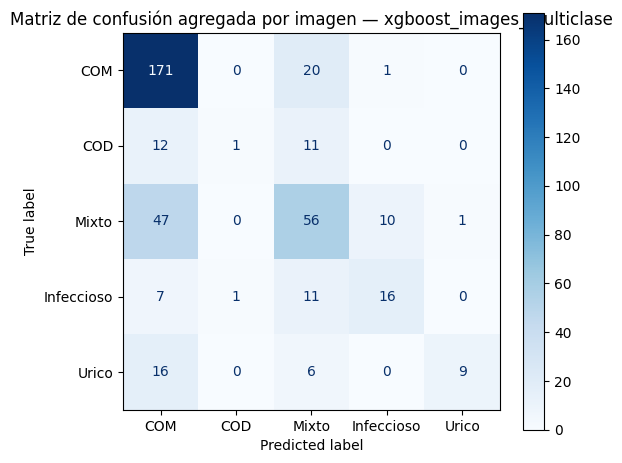

In [7]:
evaluation_result= xgboost_model.evaluate_cv(config, show_fold_metrics= True, best_params= result["best_params"])


In [10]:
#sobre las patches


patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")

task_name = "binario"
task_config = TASKS[task_name]

patches_task = assign_task_labels(patches_df_full, task_config)

xgboost_model= XGBoostExperiment(patches_task, extractor, Case.PATCH,use_energies= True )
config = {
"name": f"xgboost_images_{task_name}",
"output_dir": f"experiments/ablations/xgboost_patches/xgboost_{task_name}_energy_based",
"class_names": task_config["class_names"],
}

result= xgboost_model.search_hyperparameters(config)



  Features shape: (5290, 40)
  Distribución: {0: 2767, 1: 2523}

BÚSQUEDA HP: xgboost_images_binario
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.8151
  Best params: {'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 525, 'learning_rate': 0.02373034069425711, 'subsample': 0.5094364199009965, 'colsample_bytree': 0.6116282551239802}



EVALUACIÓN CV: xgboost_images_binario (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.7481 | precision_weighted=0.7490 | recall_weighted=0.7481 | f1_weighted=0.7482 | auc_weighted=0.8258
  Fold 2: accuracy=0.7277 | precision_weighted=0.7299 | recall_weighted=0.7277 | f1_weighted=0.7283 | auc_weighted=0.8056
  Fold 3: accuracy=0.7439 | precision_weighted=0.7515 | recall_weighted=0.7439 | f1_weighted=0.7444 | auc_weighted=0.8116
  Fold 4: accuracy=0.7385 | precision_weighted=0.7617 | recall_weighted=0.7385 | f1_weighted=0.7422 | auc_weighted=0.8155
  Fold 5: accuracy=0.7323 | precision_weighted=0.7369 | recall_weighted=0.7323 | f1_weighted=0.7323 | auc_weighted=0.8171

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7381 ± 0.0074
  auc_weighted: 0.8151 ± 0.0066
  f1_weighted: 0.7391 ± 0.0075
  precision_weighted: 0.7458 ± 0.0112
  recall_weighted: 0.7381 ± 0.0074


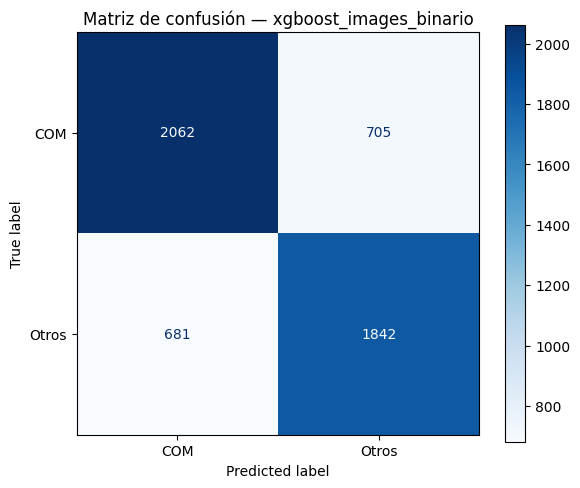


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7786 ± 0.0377
  auc_weighted: 0.8663 ± 0.0282
  f1_weighted: 0.7794 ± 0.0375
  precision_weighted: 0.7888 ± 0.0381
  recall_weighted: 0.7786 ± 0.0377


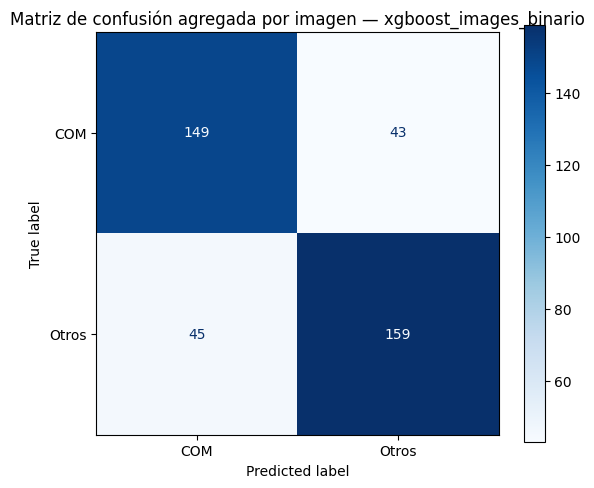

In [11]:
evaluation_result= xgboost_model.evaluate_cv(config, show_fold_metrics= True, best_params= result["best_params"])